# TPC1 - Representação de Dados e Integração Numérica

<ul>
    <li>Não deve escrever o seu nome nem nenhum código identificador em nenhum sítio. </li>
    <li>Deve entregar ESTE Notebook de Jupyter.</li>
    <li>O trabalho é individual. Podem e devem haver discussões com colegas mas o resultado entregue é individual. </li>
    <li>Não deve acrescentar ou apagar nenhuma célula. </li>
    <li>Todas as explicações devem ser claras e concisas. </li>
    <li>É preferível fazer menos e fazer bem que muito e mal. </li>
    <li>O método @jit(nopython=True) do pacote numba pode diminuir o tempo de cálculo.</li>
    <li>A não verificação de alguma destas regras leva ao anulamento e exclusão da prova.</li>
</ul>


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

np.set_printoptions(precision=12)
%matplotlib inline


# 1. Exercício - Campo elétrico de um disco ferroelétrico
O cálculo do campo eléctrico causado por uma densidade de carga fixa pode ser sempre escrito explicitamente como um integral multidimensional que soma todas as contribuições de elementos de carga no espaço. Salvo situações com grande simetria, estes integrais não são analiticamente resolúveis e os métodos de integração numérica tornam-se essenciais para resolver este problema fundamental da electroestática. Este vai ser o objectivo deste problema.<br>

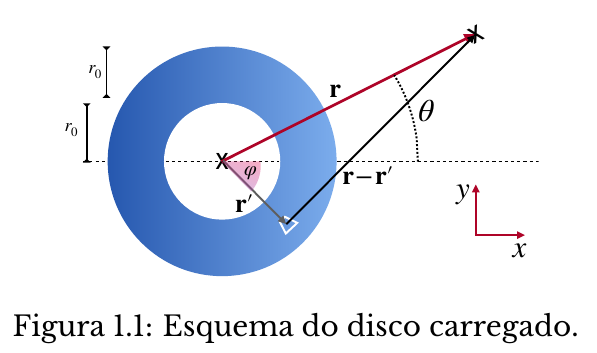

A duas dimensões, considere a coroa circular representada na Fig. 1.1 que suporta uma densidade de carga superficial fixa dada por 

$$ \sigma\left(\mathbf{r}'\right)=\sigma\left(r,\varphi\right)=\begin{cases}
\sigma_{e}\cos\left(2\varphi\right)\left(1+\cos^{3}\left(\varphi\right)\right) & \text{se }r_{0}<r<2r_{0}\\
0 & \text{outros casos}
\end{cases}, $$


onde $ \sigma_{e}$ tem unidades de carga eléctrica por unidade de área e $r_{0}$ é o raio interior da coroa circular. O potencial electrostático gerado por esta densidade de carga pode ser escrito como o seguinte integral a duas dimensões:

$$ V\!\left(\mathbf{r}\right)\!=\!\frac{1}{4\pi\varepsilon_{0}}\iint\!d^{{\scriptscriptstyle (2)}}\!\mathbf{r}^{\prime}\frac{\sigma\left(\mathbf{r}^{\prime}\right)}{\left|\mathbf{r}\!-\!\mathbf{r}^{\prime}\right|}, \,\,\,\,\,\,\,\,\,\, (1.2)$$

sendo que $\left|\mathbf{r}\!-\!\mathbf{r}^{\prime}\right|$ é dado, em termos dos ângulos $\varphi$ e $\theta$, pela expressão

$$ \left|\mathbf{r}\!-\!\mathbf{r}^{\prime}\right|=\sqrt{r^{2}\!+\!R^{2}\!-\!2rR\cos\left(\varphi\!+\!\theta\right)}, $$

onde $r\!=\!\left|\mathbf{r}^{\prime}\right|$ e $R\!=\!\left|\mathbf{r}\right|$. Usando esta parametrização, o potencial electrostático toma a forma de um integral em coordenadas polares,
$$
V\!\!\left(R,\theta\right)\!=\!\frac{\sigma_{e}}{4\pi\varepsilon_{0}}\int_{r_{0}}^{2r_{0}}\!\!\!\!\!\!\!\!rdr\!\!\int_{0}^{2\pi}\!\!\!\!\!\!\!d\varphi\frac{\cos\left(2\varphi\right)\left(1+\cos^{3}\left(\varphi\right)\right)}{\sqrt{r^{2}\!+\!R^{2}\!-\!2rR\cos\left(\varphi\!+\!\theta\right)}},\,\,\,\,\,\,\,\,\,\, (1.4)
$$
que vamos resolver e analisar nas perguntas seguintes.

<ol>
    <li>Antes de resolver o integral da Eq. 1.4, comece por escrever essa expressão em termos de quantidades adimensionais. Represente também o perfil de densidade de carga como função do ângulo polar $\varphi$.</li>
</ol>


Para adimensionalizarmos a Equ. 1.4 precisamos de escolher escalas para cada dimensão. Existem três variáveis com dimensões de comprimento, $r$, $R$ e $r_0$. Uma escolha natural é usar $r_0$ uma vez que é constante. Deste modo, 
\begin{align}
r &= r_0 r' \\
R &= r_0 R'
\end{align}
Substituindo na definição de do potencial eléctrico,
$$
V(R',\theta) = \frac{\sigma_e r_0}{4\pi \varepsilon_0} \int_1^2 dr'\, r' \int_0^{2\pi} d\varphi \frac{\cos(2\varphi)(1 + \cos^3(\varphi))}{\sqrt{r' ^2 + R^2 - 2 r 'R' \cos\left(\varphi + \theta\right) }}
$$
Com esta transformação apenas temos dimensões em $V$ e em $\sigma_e r_0 / \varepsilon_0 $. Como ambos têm exactamente as mesmas dimensões, podemos adimensionalizar o potencial através desta combinação de constantes,
\begin{align}
V' & = V \frac{4\pi \varepsilon_0}{\sigma_e r_0} \\
 & = \int_1^2 dr' \, r' \int_0^{2\pi} d\varphi \frac{\cos(2\varphi)(1 + \cos^3(\varphi))}{\sqrt{r' ^2 + R^2 - 2 r 'R' \cos\left(\varphi + \theta\right) }}
\end{align}


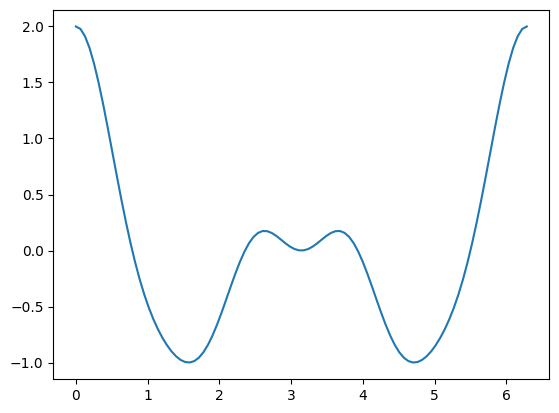

In [3]:
def sigma(phi):
    return np.cos(2*phi)*(1 + np.cos(phi)**3)

phi0 = np.linspace(0, 2*np.pi, 100)
plt.plot(phi0, sigma(phi0))


<ol start=2>
    <li> Escreva uma função que calcule numericamente o integral $V(R,\theta)$ (adimensionalizado) para um qualquer par de valores $R>0$ e $\theta\in[0,2\pi]$. Para isto, siga os seguintes passos:<br><br>
        <ol type=A>
            <li>Reescreva o integral angular usando uma nova variável — $u\!=\!\cos\varphi$ — de modo a colocar o domínio de integração no intervalo canónico $[-1,1]$. [<b>Sugestão</b>: Se dividir o domínio $\varphi\in[0,2\pi]$ em dois intervalos, pode construír dois ramos nos quais a mudança de variável é injectiva.];</li><br>
            <li>Escreva uma rotina de quadratura de Gauss-Chebyshev para calcular o integral angular como função dos parâmetros $r$, $R$ e $\theta$. [<b>Sugestão</b>: O método de quadratura de Gauss-Chebyshev para uma função $f(x)$ é dada como

$$\int_{-1}^{1}\!\!\!dxf(x)\!=\!\sum_{k=0}^{N-1}w_{k}f(x_{k})\sqrt{1\!-\!x_{k}^{2}},$$
onde $x_{k}$ são as raízes do polinómio de Chebyshev $T_{n}\left(x\right)$ e $w_{k}$ são os correspondentes pesos de quadratura. Note que $\{x_{k}\}$ e $\{w_{k}\}$ são dados por $\mathtt{numpy.polynomial.chebyshev.chebgauss(N)}$, pelo menos até $N\!=\!100]$;</li><br>
            <li>Partindo do resultado do método anterior, escreva uma rotina que calcule o integral em $r$ com o método de Simpson 1/3.</li>
        </ol>
    </li>
</ol>

Responda a esta pergunta levando em conta <b>todas</b> as sub-alíneas anteriores.

Como a transformação de coordenadas não é injectiva é melhor transformar o intervalo de integração do ângulo no intervalo de $[0,\pi]$,
\begin{align}
V(R,\theta) & = \int_1^2 dr' \int_0^{2\pi} d\varphi\, r' \frac{\cos(2\varphi)(1 + \cos^3(\varphi))}{\sqrt{r' ^2 + R^2 - 2 r 'R' \cos\left(\varphi + \theta\right) }}\\
 & = \int_1^2 dr' \int_0^{\pi} d\varphi \, r'  \frac{\cos(2\varphi)(1 + \cos^3(\varphi))}{\sqrt{r' ^2 + R^2 - 2 r 'R' \cos\left(\varphi + \theta\right) }} + \int_1^2 dr' \int_\pi^{2\pi} d\varphi\,r'  \frac{\cos(2\varphi)(1 + \cos^3(\varphi))}{\sqrt{r' ^2 + R^2 - 2 r 'R' \cos\left(\varphi + \theta\right) }} \\
& = \int_1^2 dr' \int_0^{\pi} d\varphi\,r'  \left(\frac{\cos(2\varphi)(1 + \cos^3(\varphi))}{\sqrt{r' ^2 + R^2 - 2 r 'R' \cos\left(\varphi + \theta\right) }} + \frac{\cos(2\pi + 2\varphi)(1 + \cos^3(\pi + \varphi))}{\sqrt{r' ^2 + R^2 - 2 r 'R' \cos\left(\pi + \varphi + \theta\right) }} \right) \\
\end{align}
Como $\cos(\pi + x) = -\cos(x)$ e $\cos(2\pi + x) = \cos(x)$, obtemos
\begin{align}
V(R,\theta) & = \int_1^2 dr' \int_0^{\pi} d\varphi \,r' \left( \frac{\cos(2\varphi)(1 + \cos^3(\varphi))}{\sqrt{r' ^2 + R^2 - 2 r 'R' \cos\left(\varphi + \theta\right) }} + \frac{\cos(2\varphi)(1 - \cos^3(\varphi))}{\sqrt{r' ^2 + R^2 + 2 r 'R' \cos\left( \varphi + \theta\right) }} \right)\\
\end{align}

Agora podemos com mais facilidade fazer a transformação de coordenadas, $u = \cos(\varphi)$,  
\begin{align}
u & = \cos(\varphi) \\
du & = -\sin(\varphi) d\varphi \\
d\varphi & = - \frac{du}{\sqrt{1 - u^2}} \\
\cos(\theta + \varphi) & = \cos(\theta)\cos(\varphi) - \sin{\theta} \sin{\varphi} \\
& = \cos(\theta)u) - \sin{\theta} \sqrt{1 - u^2}\\
\cos(2\varphi) & = 2 u^2 - 1
\end{align}
\begin{align}
V(R,\theta) & = \int_1^2 dr' \int_{-1}^{1} du \, r' \frac{ 2u^2 - 1}{\sqrt{1 - u^2}} \left( \frac{1 + u^3}{\sqrt{r' ^2 + R^2 - 2 r 'R' \left( \cos(\theta)u) - \sin{\theta} \sqrt{1 - u^2} \right)}} + \frac{1 - u^3}{\sqrt{r' ^2 + R^2 + 2 r 'R' \left( \cos(\theta)u) - \sin{\theta} \sqrt{1 - u^2} \right) }} \right) \\
\end{align}


In [4]:
def Gauss_integration(r, R, theta, Mphi):
    u, w = np.𝚙𝚘𝚕𝚢𝚗𝚘𝚖𝚒𝚊𝚕.𝚌𝚑𝚎𝚋𝚢𝚜𝚑𝚎𝚟.𝚌𝚑𝚎𝚋𝚐𝚊𝚞𝚜𝚜(Mphi)
    f1 = 2 * r * R * (np.cos(theta)*u - np.sin(theta) * np.sqrt(1- u**2)) 
    f = r * (2*u**2 - 1)*( (1 + u**3)/np.sqrt(r**2 + R**2 - f1) + (1 - u**3)/np.sqrt(r**2 + R**2 + f1))
    return f @ w

def Integrationr(R, theta, Mr, Mphi):
    r = np.linspace(1,2, Mr + 1)
    hr = r[1] - r[0]
    func = np.vectorize(lambda r1 : Gauss_integration(r1, R, theta, Mphi))
    f1 = func(r)
    return hr/3 *( f1[0] + f1[-1] + 4*np.sum(f1[1:-1:2]) + 2*np.sum(f1[2:-2:2]))

<ol start=3><li>Considere uma rede regular de pontos no quadrado $(x,y)\in[-5r_{0},5r_{0}]^{2}$. Utilize a função da alínea anterior para calcular $V(x,y)$ em todos os pontos dessa rede. Represente o resultado na forma de um gráfico de contorno. [<b>Sugestão</b>: $50^{2}$ pontos são suficientes para conseguir produzir um gráfico de contorno com boa resolução usando o método $\texttt{matplotlib.pyplot.contourf}]$.</li></ol>

#Responda Aqui

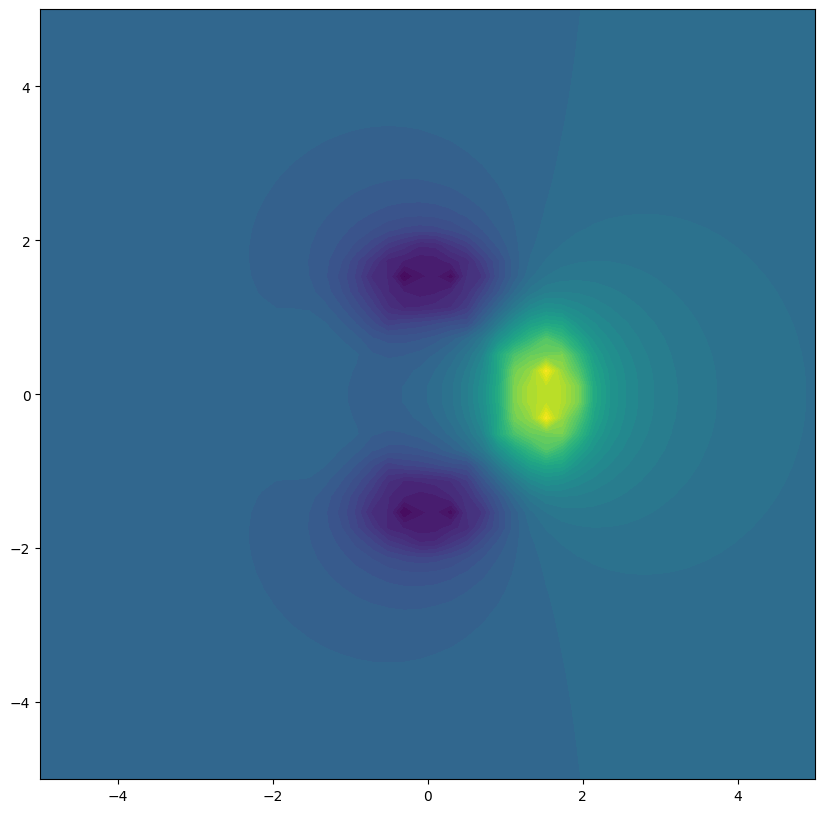

In [5]:
# Responda Aqui
M = 50
x1 = np.linspace(-5,5, M)
y1 = np.linspace(-5,5, M)
X,Y = np.meshgrid(x1,y1)
THETA = np.arctan2(Y,X)
R = np.sqrt(X**2 + Y**2)
V = np.zeros([M, M])

for i in range(M):
    for j in range(M):
        V[i,j] = Integrationr(R[i,j], THETA[i,j], 100, 40)
plt.figure(figsize=(10,10))
plt.contourf(X,Y,V,levels=50)


<ol start=4><li>Centrando-se no eixo $\theta\!=\!0$, represente $V(R,\theta\!=\!0)$ até $R\!=\!10^{7}r_{0}$. Analise o comportamento assimptótico do potencial electrostático no limite de longas distâncias. Repita a análise para $\theta\!=\!\pi/2$; Obteve o mesmo comportamento? Interprete este resultado tendo em conta o que espera para expansão multipolar de $V\!\left(\mathbf{r}\right)$. </li></ol>

#Responda Aqui

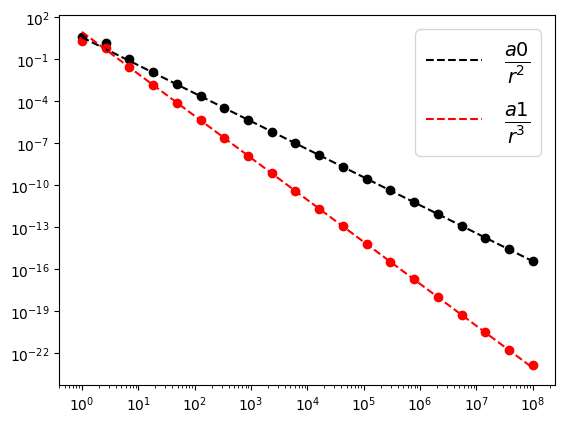

In [6]:
R = np.logspace(0,8, 20)
V = np.zeros(R.size)
for j, r in enumerate(R):
    V[j] = Integrationr(R[j], 0.0, 100, 40)
plt.plot(R,V, 'ko')

for j, r in enumerate(R):
    V[j] = Integrationr(R[j], np.pi/2, 100, 40)
plt.plot(R,np.abs(V),'ro')
plt.plot(R, 3.66/R**2,'k--', label=r"$\frac{a0}{r^2}$")
plt.plot(R, 8.8357/R**3,'r--', label=r"$\frac{a1}{r^3}$")
plt.xscale('log')
plt.yscale('log')
plt.legend(prop={"size":20})


<ol start=5><li> Formalmente, faça a expansão multipolar da Eq. 1.4 até à ordem quadrupolar. Implemente um método de Romberg adaptativo e calcule numericamente o vector dipolar eléctrico e a correcção quadrupolar para o eixo $\theta\!=\!\pi/2$. Compare estes resultados com as suas conclusões da alínea anterior. [<b>Sugestão</b>: Utilize a conhecida expansão — $1/\sqrt{1+x}\approx1-\frac{x}{2}+\frac{3x^{2}}{8}+\mathcal{O}\left(x^{3}\right)$ — e coleccione ordens apenas até $(r/R)^{2}$. No cálculo numérico coloque uma tolerância de $10^{-6}$ no erro do integral].</li></ol>

Fazendo a expansão multipolar podemos obter o potencial eléctrico a partir de um série de potências em $1/R$, 

\begin{align}
V(\boldsymbol{R}) & = \frac{Q}{R} +  \frac{\boldsymbol{R} \cdot \boldsymbol{P} }{ R^3 } + \frac{Q_{\alpha \beta} R_\alpha R_\beta}{2R^5} + \cdots
\end{align}

Onde definimos a Carga total, o vector dipolo e o tensor quadrupolo como,
\begin{align}
Q & = \int d^{(2)} \boldsymbol{r} \, \sigma(\boldsymbol{r})\\
\boldsymbol{P} & = \int d^{(2)} \boldsymbol{r}\, \boldsymbol{r} \, \sigma(\boldsymbol{r})\\ 
Q_{\alpha \beta} & = \int d^{(2)} \boldsymbol{r} \left(3 r_\alpha r_\beta - \delta_{\alpha \beta} r^2 \right) \sigma(\boldsymbol{r})\\ 
\end{align}
Aplicando ao nosso problema obtemos,
\begin{align}
Q & = \int_1^2 dr\, r \int_0^{2\pi} d\varphi \cos(2\varphi)(1 + \cos^3(\varphi))\\
P_x & = \int_1^2 dr\, r^2 \int_0^{2\pi} d\varphi \cos(\varphi)\cos(2\varphi)(1 + \cos^3(\varphi))\\ 
P_y & = \int_1^2 dr\, r^2 \int_0^{2\pi} d\varphi \cos(\varphi + \pi/2)\cos(2\varphi)(1 + \cos^3(\varphi))\\ 
Q_{y y} & = \int_1^2 dr\, r^3  \int_0^{2\pi} d\varphi \, (-1 + 3\cos^2(\varphi + \pi/2)) \cos(2\varphi)(1 + \cos^3(\varphi)) \\ 
\end{align}

Na célula abaixo calculamos a carga total, o vector momento dipolar e o tensor quadrupolo.
A carga total é nula e por isso nunca iremos ver contribuições em $1/R$. Como vector dipolo tem apenas componente segundo o eixo dos $xx'$,  quando observamos com $\theta = 0$ vemos o comportamento dipolar e quanto observamos com $\theta = \pi/2$ observamos o comportamento do quadrupolar ($1/R^3$). 

[Nota: Apesar de não ter sido pedido no exercicio, incluímos também uma análise complementar do erro associado ao tamanho do passo de integração, como função da ordem de extrapolação no método de Romberg. Esta análise não será avaliada.]


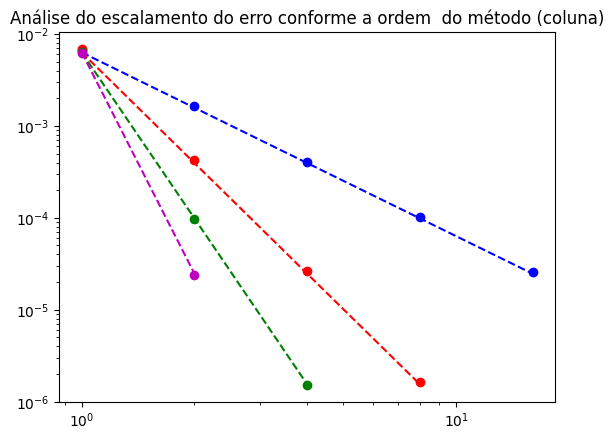


### Calculo dos coeficientes:


Carga Total: -2.0927210988051795e-15
Px =  3.6651914291880896
Py =  6.717263620226557e-16
Qyy =  -17.67145867644258


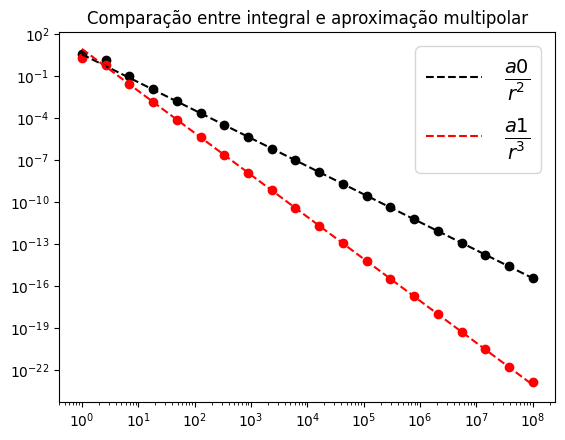

In [7]:
def Romberg(f,a, b,  epsilon ):
    M = 16 
    h = (b -a)/M
    order = 1
    erro = 1.
    integral = np.zeros([order,order],dtype=float) 
    
    x0 = np.linspace(a, b, M + 1)    
    f0 = f(x0)
    S1 = f0[0] + f0[-1]
    S2 = f0[1:-1].sum()
    integral[0,0] = h/2 * (S1 + 2*S2) 
    
    while (np.abs(erro) > epsilon): 
        x1 = np.linspace(a + h/2, b - h/2, M)  
        h /= 2 
        M *= 2
        S2 += np.sum(f(x1))
        tmp = np.zeros([order + 1, order + 1])
        tmp[:order, :order] = integral[:,:]
        integral = tmp
        integral[order, 0] = h/2 *(S1 + 2*S2)
        for i in range(1, order + 1):
            denom = 2**(2 * i) - 1
            erro = (integral[order, i - 1] - integral[order - 1, i -1]) / denom
            integral[order, i] = integral[order, i - 1] + erro
        order += 1
    return integral

# Testar o método de Romberg 
def f1(x):
    return np.sin(10*x)

integ = np.abs(Romberg(f1,0, np.sqrt(2), 1E-12  ) - 0.10049686621325937736) # Resultado exacto do integral
M = len(integ)
plt.title("Análise do escalamento do erro conforme a ordem  do método (coluna)")
lls = 2**np.arange(M)
plt.plot(lls, integ[:,0], 'bo')
plt.plot(lls, lls**(-2.) * 10**(-2.2),'b--' )

plt.plot(lls[:-1], integ[1:,1] * 10**2.5, 'ro')
plt.plot(lls[:-1], lls[:-1]**(-4.) * 10**(-2.2),'r--' )

plt.plot(lls[:-2], integ[2:,2] * 10**5.4,'go')
plt.plot(lls[:-2], lls[:-2]**(-6.) * 10**(-2.2),'g--' )

plt.plot(lls[:-3], integ[3:,3] * 10**8.9,'mo')
plt.plot(lls[:-3], lls[:-3]**(-8.) * 10**(-2.2),'m--' )

plt.yscale('log')
plt.xscale('log')
plt.show()
# Calculo dos coeficientes da expansão multipolar

def fphiQ(phi1):
    return np.cos(2*phi1)*(1 + np.cos(phi1)**3)
def fphiPx(phi1):
    return fphiQ(phi1)*np.cos(phi1)
def fphiPy(phi1):
    return fphiQ(phi1)*np.cos(phi1 + np.pi/2)
def fphiQyy(phi1):
    return fphiQ(phi1)*( -1 + 3*np.cos(phi1 + np.pi/2)**2)
Qtotal = Romberg(lambda r: r   ,1,2, 1E-8  )[-1,-1] * Romberg(fphiQ , 0,2*np.pi, 1E-8  )[-1,-1]
Px     = Romberg(lambda r: r**2,1,2, 1E-8  )[-1,-1] * Romberg(fphiPx, 0,2*np.pi, 1E-8  )[-1,-1]
Py     = Romberg(lambda r: r**2,1,2, 1E-8  )[-1,-1] * Romberg(fphiPy, 0,2*np.pi, 1E-8  )[-1,-1]
Qyy    = Romberg(lambda r: r**3,1,2, 1E-8  )[-1,-1] * Romberg(fphiQyy,0,2*np.pi, 1E-8  )[-1,-1]


display(Markdown(r"""
### Calculo dos coeficientes:
"""))
print("Carga Total:", Qtotal)
print("Px = ", Px)
print("Py = ", Py)
print("Qyy = ",  Qyy)

plt.title("Comparação entre integral e aproximação multipolar")
R = np.logspace(0,8, 20)
V = np.zeros(R.size)
for j, r in enumerate(R):
    V[j] = Integrationr(R[j], 0.0, 100, 40)
plt.plot(R,V, 'ko')

for j, r in enumerate(R):
    V[j] = Integrationr(R[j], np.pi/2, 100, 40)
plt.plot(R,np.abs(V),'ro')
plt.plot(R, Px/R**2,'k--', label=r"$\frac{a0}{r^2}$")
plt.plot(R, np.abs(Qyy)/2/R**3,'r--', label=r"$\frac{a1}{r^3}$")
plt.xscale('log')
plt.yscale('log')
plt.legend(prop={"size":20})
plt.show()

# 2. Exercício - Carga Induzida Num Condutor Perfeito

No exercício anterior determinou-se o potencial eléctrico causado pela distribuição de carga estática na coroa circular. 

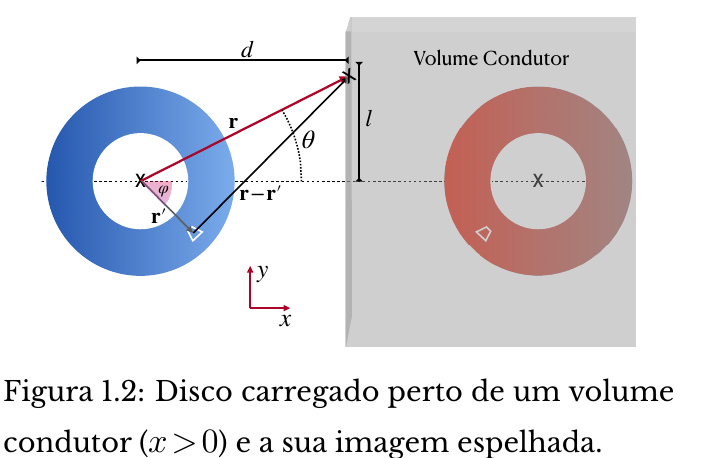

No entanto, se esta for colocada nas proximidades de um condutor volúmico ideal (como representado na Fig. 1.2), uma distribuição de cargas será induzida na superfície do condutor $(x\!=\!0)$ de modo a anular o campo no seu interior. Tomando esta carga superficial em consideração, o campo elétrico passa a ser perpedicular à superficie do condutor, sendo $E_{x}\left(x\right)$ uma função descontínua a $x\!=\!0$. Para calcular <b>o campo elétrico fora do volume condutor</b> podemos usar o método das imagens, onde se sobrepõem os campos criados pelo disco e pela sua imagem reflectida de carga oposta (como representado na Fig. 1.2).

<ol><li>Usando a Eq. 1.2, mostre que a componente segundo $x$ do campo eléctrico devido apenas à coroa circular pode ser escrita como:

$$ 
E_{x}\left(R,\theta\right)=\!\frac{\sigma_{e}}{4\pi\varepsilon_{0}}\int_{r_{0}}^{2r_{0}}\!\!\!\!\!\!\!\!rdr\!\!\int_{0}^{2\pi}\!\!\!\!\!\!\!d\varphi\frac{\left(R\cos\theta-r\cos\varphi\right)\cos\left(2\varphi\right)\left(1+\cos^{3}\left(\varphi\right)\right)}{\left(r^{2}\!+\!R^{2}\!-\!2rR\cos\left(\varphi\!+\!\theta\right)\right)^{\frac{3}{2}}}.\,\,\,\,\,\,\,\,\,\, (1.5) $$
    [<b>Sugestão:</b> Note que $E_{x}\!=\!-\partial V(\mathbf{r})/\partial x.]$</li>
</ol>

A componente do campo (adimensionalizado) segundo o $xx'$ é dada por,
\begin{align}
E_x & = - \frac{\partial V}{\partial x} \\
&= -\frac{\partial }{\partial x} \int_1^2 dr\,r \int_0^{2\pi} d\varphi \frac{\cos(2\varphi) (1 + \cos^3 (\varphi))}{\sqrt{r^2 + y^2 + x^2 - 2 r \cos(\varphi) x + 2 r \sin(\varphi) y}}\\
&=  \int_1^2 dr\,r \int_0^{2\pi} d\varphi \frac{\cos(2\varphi) (1 + \cos^3 (\varphi)) (x - r \cos(\varphi))
}{\left(r^2 + x^2 + y^2 - 2 r x \cos(\varphi)  + 2 r y\sin(\varphi) \right)^{3/2}}\\
&=  \int_1^2 dr\,r \int_0^{2\pi} d\varphi \frac{\cos(2\varphi) (1 + \cos^3 (\varphi)) (x - r \cos(\varphi))
}{\left(r^2 + R^2 - 2 r R \cos(\varphi + \theta) \right)^{3/2}}\\
\end{align}

In [8]:
# Responda Aqui

<ol start=2><li> A partir da Eq. 1.5, deduza a seguinte expressão do campo $E_{x}$ <b>causado pela coroa circular carregada</b> em $x\!=\!0$ como função da distância $(l)$ ao eixo tracejado na Fig. 1.2:

$$ E_{x}\left(l\right)=\!\frac{\sigma_{e}}{4\pi\varepsilon_{0}}\int_{r_{0}}^{2r_{0}}\!\!\!\!\!\!\!\!rdr\!\!\int_{0}^{2\pi}\!\!\!\!\!\!\!d\varphi\frac{\left(d-r\cos\varphi\right)\cos\left(2\varphi\right)\left(1+\cos^{3}\left(\varphi\right)\right)}{\left(r^{2}\!+\!d^{2}\!+l^{2}\!-\!2r\left[d\cos\left(\varphi\right)\!-\!l\sin\left(\varphi\right)\right]\right)^{\frac{3}{2}}}. $$

</li>
</ol>

Partindo da expressão obtida na alínea anterior e substituindo $l = d \cos(\theta)$ e $d = R \sin(\theta)$ obtemos directamente a expressão anterior.


In [9]:
# Responda Aqui

<ol start=3><li> Utilizando o método das imagens — Fig. 1.2 — generalize a expressão anterior para o campo $E_x$ completo criado pelo anel e a sua imagem de espelho.</li></ol>

Na alínea 2 calculou-se o campo elétrico criado pela coroa circular na superficie do volume condutor (a $x=0$). Pelo método das imagens, o campo completo, incluíndo o que é gerado pelas cargas livres do volume condutor, é dada pela sobreposição entre o campo criado pela coroa e pela sua imagem espelhada com carga oposta (tal como se mostra na Fig.1.2). O campo dentro do volume condutor é zero - $\overrightarrow{E}(x>0,y)=\overrightarrow{0}$.
    

   Por simetria, o campo criado pela imagem espelhada na fronteira do condutor é exactamente igual a $\overrightarrow{E}_{\text{im}}(x\!=\!0,y)=\left(E_{\text{co}}^{x}(x\!=\!0,y),-E_{\text{co}}^{y}(x\!=\!0,y)\right)$, onde $\overrightarrow{E}_{\text{co}}(x\!=\!0,y)$ é o campo criado pela coroa apenas. Assim sendo, o campo completo na fronteira do condutor é
   
   
   $$\overrightarrow{E}_{\!\text{tot}}\left(l\right)=\!\frac{\sigma_{e}\mathbf{x}}{2\pi\varepsilon_{0}}\int_{r_{0}}^{2r_{0}}\!\!\!\!\!\!\!\!rdr\!\!\int_{0}^{2\pi}\!\!\!\!\!\!\!d\varphi\frac{\left(d-r\cos\varphi\right)\cos\left(2\varphi\right)\left(1+\cos^{3}\left(\varphi\right)\right)}{\left(r^{2}\!+\!d^{2}\!+l^{2}\!-\!2r\left[d\cos\left(\varphi\right)\!-\!l\sin\left(\varphi\right)\right]\right)^{\frac{3}{2}}}.$$


In [10]:
# Responda Aqui

<ol start=4><li>Construa uma função $\mathtt{python}$ que calcule numericamente o integral da equação da alínea anterior e devolva $E_{x}$ para qualquer valor $l\in\mathbb{R}$ na superfície externa do condutor (assuma $d\!=\!5r_{0}$). [<b>Sugestão</b>: Siga um procedimento semelhante ao que utilizou na alínea 2 do Exercício 1] </li>
</ol>

Antes de resolver o integral anterior numericamente, começamos por adimensionalizar as variáveis. Para isso definimos $\mathcal{E}^x_{\!\text{tot}}=\frac{\varepsilon_0}{\sigma_e}E^x_{\!\text{tot}}$, $\tilde{d}=d/r_0$, $\tilde{l}=l/r_0$, $\tilde{r}=r/r_0$. Deste modo ficamos com o seguinte integral:

$$\mathcal{E}^x_{\!\text{tot}}\left(\tilde{l}\right)=\!\frac{1}{2\pi}\int_{1}^{2}\!\!\!\!\!\!\tilde{r}d\tilde{r}\!\!\int_{0}^{2\pi}\!\!\!\!\!\!\!\tilde{d}\varphi\frac{\left(\tilde{d}-\tilde{r}\cos\varphi\right)\cos\left(2\varphi\right)\left(1+\cos^{3}\left(\varphi\right)\right)}{\left(\tilde{r}^{2}\!+\!\tilde{d}^{2}\!+\tilde{l}^{2}\!-\!2\tilde{r}\left[\tilde{d}\cos\left(\varphi\right)\!-\!\tilde{l}\sin\left(\varphi\right)\right]\right)^{\frac{3}{2}}}.$$

Agora, tal como fizemos no problema 1.2, efectuamos uma separação do domínio de integração angular em $\varphi\in [0,\pi]$ e $\varphi\in [\pi,2\pi]$, efectuando depois a mudança de variável -- $u\!=\!\cos{\varphi}$ -- que é injectiva em cada sub-intevalo. A redução do domínio angular dá origem a

$$\mathcal{E}_{\!\text{tot}}^{x}\left(\tilde{l}\right)	=\!\frac{1}{2\pi}\int_{1}^{2}\!\!\!\!\!\!\tilde{r}d\tilde{r}\!\!\int_{0}^{\pi}\!\!\!\!\!\!\!d\varphi\frac{\left(\tilde{d}-\tilde{r}\cos\varphi\right)\cos\left(2\varphi\right)\left(1+\cos^{3}\left(\varphi\right)\right)}{\left(\tilde{r}^{2}\!+\!\tilde{d}^{2}\!+\tilde{l}^{2}\!-\!2\tilde{r}\left[\tilde{d}\cos\left(\varphi\right)\!-\!\tilde{l}\sin\left(\varphi\right)\right]\right)^{\frac{3}{2}}}
	\qquad\qquad\qquad\qquad+\frac{\left(\tilde{d}+\tilde{r}\cos\varphi\right)\cos\left(2\varphi\right)\left(1-\cos^{3}\left(\varphi\right)\right)}{\left(\tilde{r}^{2}\!+\!\tilde{d}^{2}\!+\tilde{l}^{2}\!+\!2\tilde{r}\left[\tilde{d}\cos\left(\varphi\right)\!-\!\tilde{l}\sin\left(\varphi\right)\right]\right)^{\frac{3}{2}}},$$

enquanto que a mudança de variável nos leva à expressão final:

$$\mathcal{E}_{\!\text{tot}}^{x}\left(\tilde{l}\right)=\!\frac{1}{2\pi}\int_{1}^{2}\!\!\!\!\!\!\tilde{r}d\tilde{r}\!\!\int_{-1}^{1}\!\!\!\!\!\frac{du}{\sqrt{1\!-\!u^{2}}}\frac{\left(\tilde{d}-\tilde{r}u\right)\left(2u^{2}\!-\!1\right)\left(1+u^{3}\right)}{\left(\tilde{r}^{2}\!+\!\tilde{d}^{2}\!+\tilde{l}^{2}\!-\!2\tilde{r}\left[\tilde{d}u\!-\!\tilde{l}\sqrt{1\!-\!u^{2}}\right]\right)^{\frac{3}{2}}}\qquad\qquad\qquad\qquad+\frac{\left(\tilde{d}+\tilde{r}u\right)\left(2u^{2}\!-\!1\right)\left(1-u^{3}\right)}{\left(\tilde{r}^{2}\!+\!\tilde{d}^{2}\!+\tilde{l}^{2}\!+\!2\tilde{r}\left[\tilde{d}u\!-\!\tilde{l}\sqrt{1-u^{2}}\right]\right)^{\frac{3}{2}}}.$$
    
Para cada valor de $\tilde{l}$, $\tilde{d}=5$ e $\tilde{r}$ fixo. podemos agora avaliar o integral em $u$ usando uma quadratura de Gauss-Chebyshev, integrando depois o resultado em $\tilde{r}$ usando um método de Simpson-1/3. Isto é feito na célula de código seguinte.

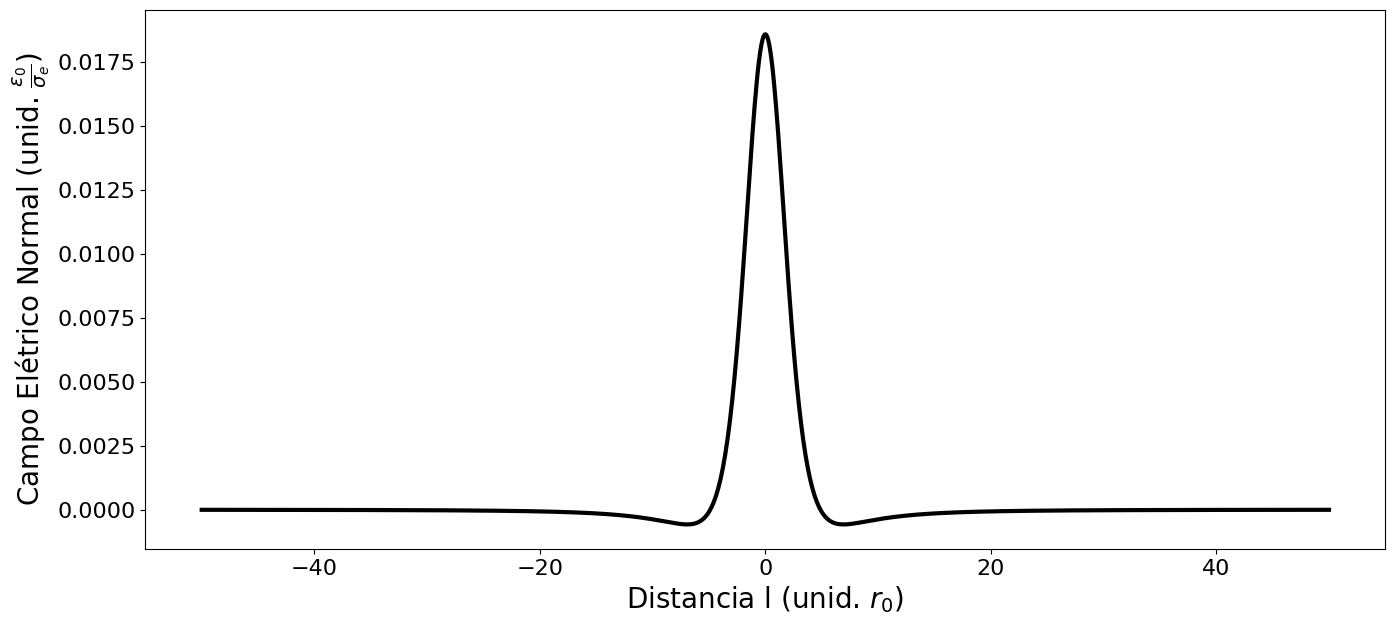

In [11]:
def Gauss_integration(r,l,Mphi):
    d = 5 # Distancia fixa a 5r0
    u, w = np.𝚙𝚘𝚕𝚢𝚗𝚘𝚖𝚒𝚊𝚕.𝚌𝚑𝚎𝚋𝚢𝚜𝚑𝚎𝚟.𝚌𝚑𝚎𝚋𝚐𝚊𝚞𝚜𝚜(Mphi)
    f1 = 2 * r * (d*u - l*np.sqrt(1- u**2)) 
    f = r * (2*u**2 - 1)*((d - r*u)*(1 + u**3)/((r**2 + d**2 + l**2 - f1)**(3/2)) + (d + r*u)*(1 - u**3)/((r**2 + d**2 + l**2 + f1)**(3/2)))
    return f @ w

def Integrationr(l,Mr,Mphi):
    r = np.linspace(1,2, Mr + 1)
    hr = r[1] - r[0]
    func = np.vectorize(lambda r1 : Gauss_integration(r1,l,Mphi))
    f1 = func(r)
    return (1/(2*np.pi)) * hr/3 *( f1[0] + f1[-1] + 4*np.sum(f1[1:-1:2]) + 2*np.sum(f1[2:-2:2]))# Responda Aqui

Mphi = 40; Mr = 100

ll = np.linspace(-50,50,1000)
EE = np.zeros(len(ll))
for i in range(len(ll)):
    EE[i] = Integrationr(ll[i],Mr,Mphi)
 
#Teste - Cálculo do E^x como função de l

plt.figure(figsize=(16,7))
plt.plot(ll,EE,'k',linewidth=3.0)
plt.xlabel(r"Distancia l (unid. $r_0$)",fontsize=20)
plt.ylabel(r"Campo Elétrico Normal (unid. $\frac{\varepsilon_0}{\sigma_e}$)",fontsize=20)
plt.xticks(fontsize=16); plt.yticks(fontsize=16)
plt.show()

<ol start=5><li>Utilizando a Lei de Gauss integral, calcule e represente graficamente a densidade superficial de carga induzida na superfície do condutor perfeito como função de $l$. Qual é o comportamento de $\sigma_{c}\left(l\right)$ no limite de $l\to\pm\infty$? Comente.</li>
</ol>

Bom Trabalho

Como foi visto anteriormente, na presença do volume condutor, o campo elétrico é zero para $x>0$ mas é finito e perpendicular à superficie condutora para $x<0$. A aplicação da Lei de Gauss integral (fluxo do campo elétrico por uma superficie fechada é igual a $Q/\varepsilon_0$, onde $Q$ é a carga elétrica no interior). A aplicação desta lei a uma "caixa" de bases paralelas à superficie $x=0$ e altura infinitesimal permite relacionar a densidade de carga elétrica induzida na superficie do condutor, com a descontinuídade do campo elétrico perpendicula. Mais precisamente temos:

$$\sigma_{\text{ind}}\!(l)\!=\!\varepsilon_{0}\left[-E_{\text{tot}}^{x}\!\left(x\!\to\!0^{-}\right)\!+E_{\text{tot}}^{x}\!\left(x\!\to\!0^{+}\right)\right]=-\sigma_{e}\mathcal{E}_{\!\text{tot}}^{x}\left(l/r_{0}\right)$$.

Podemos então representar $\sigma_{\text{ind}}\!(l)$ utilizando o resultado do cálculo anterior. Note-se que, maioritariamente, a densidade de carga induzida é negativa e comporta-se como $\propto l^{-3}$, como esperado por um campo dipolar a grandes distâncias.

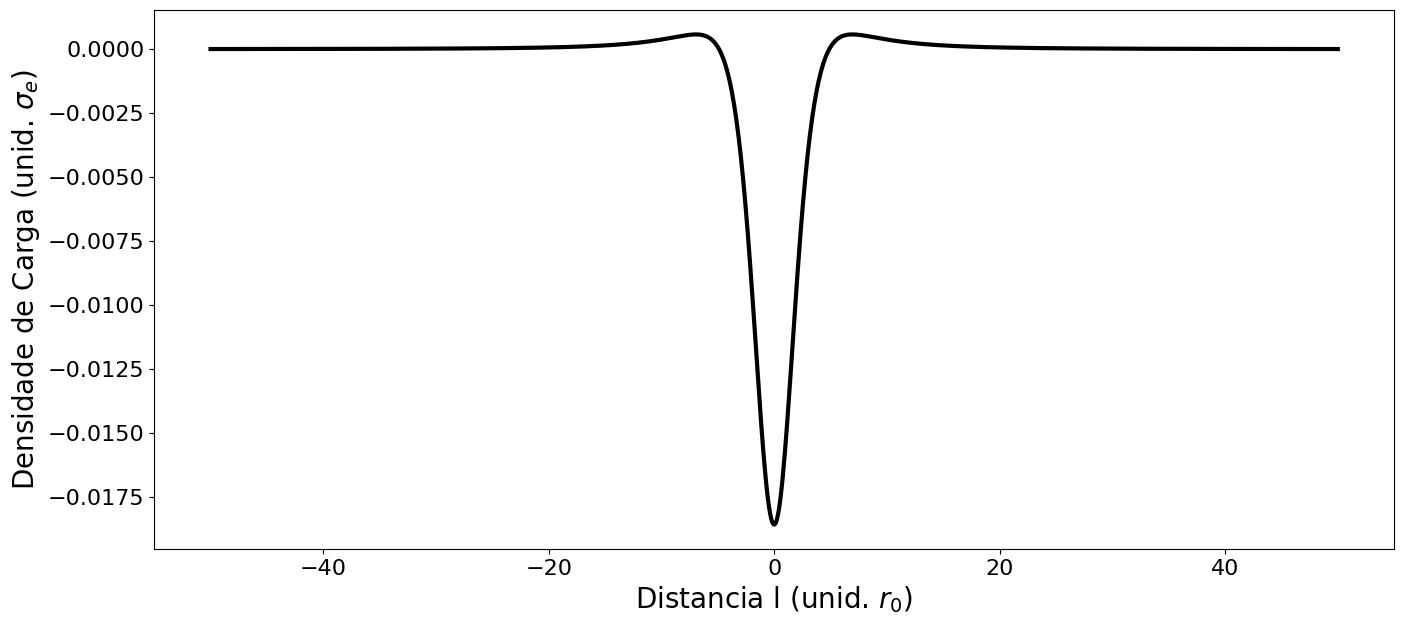

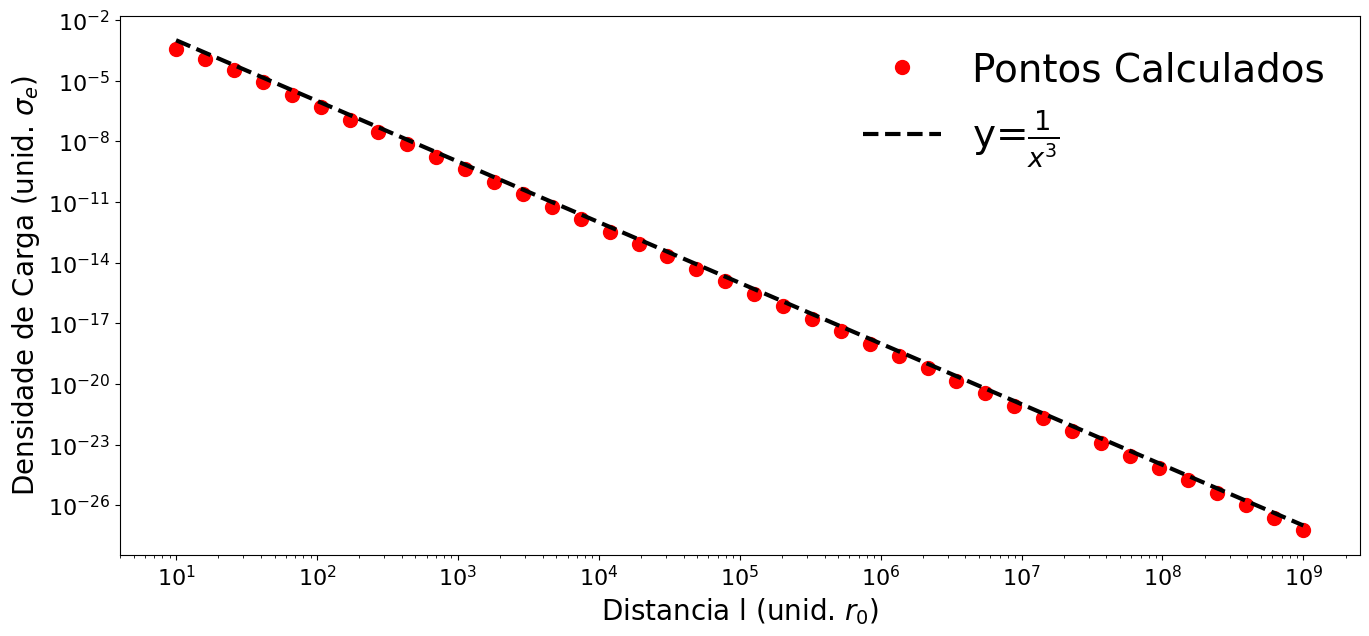

In [12]:
Mphi = 40; Mr = 100

ll = np.linspace(-50,50,1000)
sigma = np.zeros(len(ll))
for i in range(len(ll)):
    sigma[i] = -Integrationr(ll[i],Mr,Mphi)
    
#Teste - Cálculo do sigma_ind como função de l

plt.figure(figsize=(16,7))
plt.plot(ll,sigma,'k',linewidth=3.0)
plt.xlabel(r"Distancia l (unid. $r_0$)",fontsize=20)
plt.ylabel(r"Densidade de Carga (unid. $\sigma_e$)",fontsize=20)
plt.xticks(fontsize=16); plt.yticks(fontsize=16)
plt.show()

# Análise do comportamento das caudas

Mphi = 40; Mr = 100

ll = np.logspace(1,9,40)
sigma = np.zeros(len(ll))
for i in range(len(ll)):
    sigma[i] = -Integrationr(ll[i],Mr,Mphi)
    
plt.figure(figsize=(16,7))
plt.plot(ll,sigma,'ro',markersize=10.,label="Pontos Calculados")
plt.plot(ll,1/ll**3,'k--',linewidth=3.0,label=r"y=$\frac{1}{x^3}$")
plt.xlabel(r"Distancia l (unid. $r_0$)",fontsize=20)
plt.ylabel(r"Densidade de Carga (unid. $\sigma_e$)",fontsize=20)
plt.xticks(fontsize=16); plt.yticks(fontsize=16)
plt.xscale('log'); plt.yscale('log')
plt.legend(frameon=False,fontsize=28)
plt.show()